In [1]:
from pathlib import Path
import json

DATA_ROOT = Path("batch_50_random")  # <-- CHANGE THIS

samples = sorted([p for p in DATA_ROOT.glob("sample_*") if p.is_dir()])
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("Num samples:", len(samples))
print("First sample:", samples[0] if samples else None)

params = json.loads((samples[0] / "parameters.json").read_text())
print("Parameter keys:", list(params.keys()))
print("Example params:", params)


DATA_ROOT exists: True
Num samples: 50
First sample: batch_50_random\sample_0000
Parameter keys: ['th_necro_n', 'th_enhancing_p', 'th_edema_p', 'Dw', 'rho', 'lambda_np', 'sigma_np', 'D_s', 'lambda_s', 'gm_path', 'wm_path', 'NxT1_pct', 'NyT1_pct', 'NzT1_pct', 'resolution_factor', 'RatioDw_Dg', 'th_matter', 'th_necro', 'dx_mm', 'dy_mm', 'dz_mm', 'init_scale', 'time_series_solution_Nt', 'Nt_multiplier', 'output_dir']
Example params: {'th_necro_n': 0.15621088666940686, 'th_enhancing_p': 0.25720457300353083, 'th_edema_p': 0.24548647782429914, 'Dw': 1.4363502971184063, 'rho': 0.4778214378844623, 'lambda_np': 0.4659969709057026, 'sigma_np': 0.3993292420985183, 'D_s': 0.8900466011060912, 'lambda_s': 0.055238410897498764, 'gm_path': './dataset/GM.nii.gz', 'wm_path': './dataset/WM.nii.gz', 'NxT1_pct': 0.36742508365045984, 'NyT1_pct': 0.6098528437324806, 'NzT1_pct': 0.5303345035229626, 'resolution_factor': 0.65, 'RatioDw_Dg': 17.48663961200633, 'th_matter': 0.1, 'th_necro': 0.9, 'dx_mm': 1.0, 'dy

In [2]:
TARGET_KEYS = ("Dw", "rho") 


In [3]:
import random
random.seed(42)
random.shuffle(samples)

n = len(samples)
train = samples[:int(0.7*n)]
val   = samples[int(0.7*n):int(0.85*n)]
test  = samples[int(0.85*n):]

print("Split sizes:", len(train), len(val), len(test))


Split sizes: 35 7 8


In [4]:
import numpy as np
import json

def get_y(sample_dir):
    p = json.loads((sample_dir/"parameters.json").read_text())
    return np.array([float(p[k]) for k in TARGET_KEYS], dtype=np.float32)

Y_train = np.stack([get_y(s) for s in train], axis=0)
Y_MEAN = Y_train.mean(axis=0)
Y_STD  = Y_train.std(axis=0) + 1e-6

print("Y_MEAN:", Y_MEAN)
print("Y_STD :", Y_STD)


Y_MEAN: [1.7833216 0.2844008]
Y_STD : [0.8459725  0.13039392]


In [5]:
import numpy as np
import SimpleITK as sitk
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import json

def read_nii(path):
    img = sitk.ReadImage(str(path))
    arr = sitk.GetArrayFromImage(img).astype(np.float32)  # (D,H,W)
    return arr

def bbox_from_mask(mask, margin=12):
    idx = np.argwhere(mask)
    if idx.size == 0:
        return None
    z0,y0,x0 = idx.min(axis=0)
    z1,y1,x1 = idx.max(axis=0) + 1
    z0 = max(z0 - margin, 0); y0 = max(y0 - margin, 0); x0 = max(x0 - margin, 0)
    z1 = min(z1 + margin, mask.shape[0]); y1 = min(y1 + margin, mask.shape[1]); x1 = min(x1 + margin, mask.shape[2])
    return (z0,z1,y0,y1,x0,x1)

def crop(arr, bb):
    z0,z1,y0,y1,x0,x1 = bb
    return arr[z0:z1, y0:y1, x0:x1]

def resize_3d(arr, out_shape=(96,96,96)):
    t = torch.from_numpy(arr)[None,None,...]
    t = F.interpolate(t, size=out_shape, mode="trilinear", align_corners=False)
    return t[0,0].numpy()

def normalize_channel(arr):
    m = arr.mean()
    s = arr.std()
    return (arr - m) / (s + 1e-6)

class TumorParamDataset(Dataset):
    def __init__(self, sample_dirs, input_mode="physics", out_shape=(96,96,96), target_keys=("Dw","rho","D_s")):
        self.sample_dirs = sample_dirs
        self.input_mode = input_mode
        self.out_shape = out_shape
        self.target_keys = target_keys

    def __len__(self):
        return len(self.sample_dirs)

    def __getitem__(self, idx):
        sd = self.sample_dirs[idx]

        # ---- Targets (normalized using training stats) ----
        params = json.loads((sd/"parameters.json").read_text())
        y_raw = np.array([float(params[k]) for k in self.target_keys], dtype=np.float32)
        y_norm = (y_raw - Y_MEAN) / Y_STD
        y = torch.tensor(y_norm, dtype=torch.float32)

        # ---- Inputs ----
        segm = read_nii(sd/"segm.nii.gz")
        bb = bbox_from_mask(segm > 0, margin=12)

        if self.input_mode == "physics":
            chans = [
                read_nii(sd/"P.nii.gz"),
                read_nii(sd/"N.nii.gz"),
                read_nii(sd/"S.nii.gz"),
                (segm > 0).astype(np.float32),
            ]
        else:  # imaging
            chans = [
                read_nii(sd/"FET.nii.gz"),
                read_nii(sd/"wm_data.nii.gz"),
                read_nii(sd/"gm_data.nii.gz"),
                (segm > 0).astype(np.float32),
            ]

        processed = []
        for c in chans:
            if bb is not None:
                c = crop(c, bb)
            c = resize_3d(c, self.out_shape)

            # normalize non-binary channels
            if np.unique(c).size > 2:
                c = normalize_channel(c)

            processed.append(c)

        x = torch.from_numpy(np.stack(processed, axis=0)).float()  # (C,D,H,W)
        return x, y


In [6]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
import torch

class CNN3DRegressor(nn.Module):
    def __init__(self, in_channels, out_dim):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(in_channels, 32, 3, padding=1),
            nn.BatchNorm3d(32), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(32, 64, 3, padding=1),
            nn.BatchNorm3d(64), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(64, 128, 3, padding=1),
            nn.BatchNorm3d(128), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(128, 256, 3, padding=1),
            nn.BatchNorm3d(256), nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, out_dim)
        )

    def forward(self, x):
        return self.head(self.features(x))

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, torch.cuda.get_device_name(0) if device=="cuda" else "")

MODE = "physics"      # start here; later set to "imaging"
OUT_SHAPE = (96,96,96)

train_ds = TumorParamDataset(train, input_mode=MODE, out_shape=OUT_SHAPE, target_keys=TARGET_KEYS)
val_ds   = TumorParamDataset(val,   input_mode=MODE, out_shape=OUT_SHAPE, target_keys=TARGET_KEYS)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=2, shuffle=False, num_workers=0, pin_memory=True)

model = CNN3DRegressor(in_channels=4, out_dim=len(TARGET_KEYS)).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scaler = GradScaler()
loss_fn = nn.MSELoss()

def mae(pred, y): 
    return (pred - y).abs().mean()

EPOCHS = 80

for epoch in range(1, EPOCHS+1):
    model.train()
    tr_loss = tr_mae = 0.0
    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with autocast():
            pred = model(x)
            loss = loss_fn(pred, y)

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        tr_loss += loss.item()
        tr_mae  += mae(pred.detach(), y).item()

    model.eval()
    va_loss = va_mae = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            pred = model(x)
            va_loss += loss_fn(pred, y).item()
            va_mae  += mae(pred, y).item()

    print(f"Epoch {epoch:03d} | train MSE {tr_loss/len(train_loader):.4f} MAE {tr_mae/len(train_loader):.4f} "
          f"| val MSE {va_loss/len(val_loader):.4f} MAE {va_mae/len(val_loader):.4f}")


Device: cuda NVIDIA GeForce RTX 5080


C:\Users\Grant\AppData\Local\Temp\ipykernel_26504\3894520923.py:50: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\Grant\AppData\Local\Temp\ipykernel_26504\3894520923.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 001 | train MSE 0.9294 MAE 0.8442 | val MSE 3.6279 MAE 1.6926
Epoch 002 | train MSE 0.8560 MAE 0.7837 | val MSE 2.5737 MAE 1.4270
Epoch 003 | train MSE 0.6937 MAE 0.7184 | val MSE 0.7937 MAE 0.6795
Epoch 004 | train MSE 0.7503 MAE 0.7683 | val MSE 1.0746 MAE 0.9575
Epoch 005 | train MSE 0.7060 MAE 0.7240 | val MSE 1.1729 MAE 0.9063
Epoch 006 | train MSE 0.6775 MAE 0.7047 | val MSE 2.2845 MAE 1.1150
Epoch 007 | train MSE 0.7314 MAE 0.7180 | val MSE 0.7104 MAE 0.6781
Epoch 008 | train MSE 0.5604 MAE 0.6352 | val MSE 0.7124 MAE 0.6144
Epoch 009 | train MSE 0.7229 MAE 0.6985 | val MSE 1.2092 MAE 0.8627
Epoch 010 | train MSE 0.7144 MAE 0.7261 | val MSE 0.6026 MAE 0.6380
Epoch 011 | train MSE 0.5246 MAE 0.6246 | val MSE 1.2786 MAE 0.7137
Epoch 012 | train MSE 0.6366 MAE 0.6552 | val MSE 0.6286 MAE 0.5698
Epoch 013 | train MSE 0.5955 MAE 0.6311 | val MSE 0.5893 MAE 0.5828
Epoch 014 | train MSE 0.5835 MAE 0.6578 | val MSE 0.8665 MAE 0.6408
Epoch 015 | train MSE 0.7766 MAE 0.7527 | val MS

Dw: MAE=0.637806 RMSE=0.717430
rho: MAE=0.031710 RMSE=0.037169


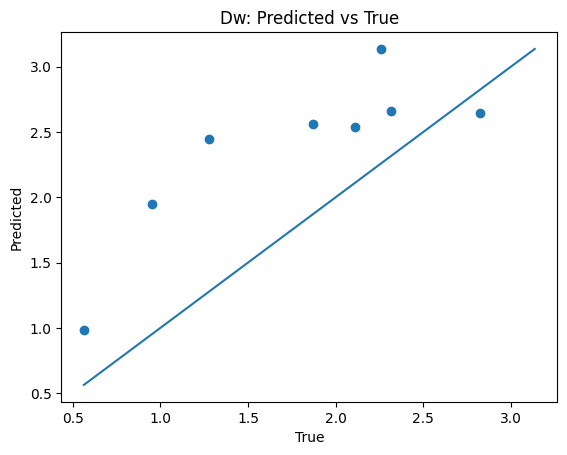

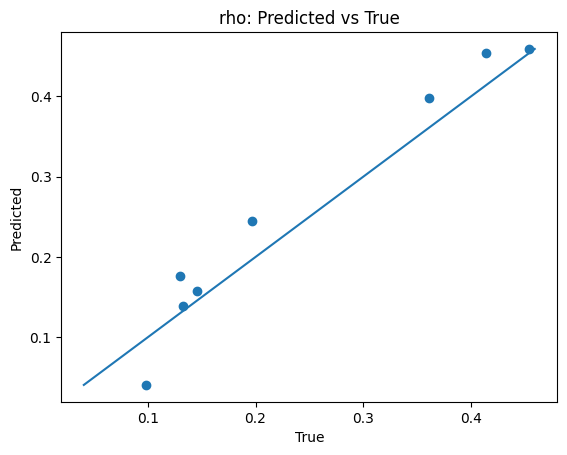

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch

test_ds = TumorParamDataset(test, input_mode=MODE, out_shape=OUT_SHAPE, target_keys=TARGET_KEYS)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

model.eval()
preds_norm, trues_norm = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        pred = model(x).cpu().numpy()[0]
        preds_norm.append(pred)
        trues_norm.append(y.numpy()[0])

preds_norm = np.array(preds_norm)
trues_norm = np.array(trues_norm)

# Denormalize back to original parameter scale
preds = preds_norm * Y_STD + Y_MEAN
trues = trues_norm * Y_STD + Y_MEAN

for i,k in enumerate(TARGET_KEYS):
    mae_i = np.abs(preds[:,i] - trues[:,i]).mean()
    rmse_i = np.sqrt(((preds[:,i] - trues[:,i])**2).mean())
    print(f"{k}: MAE={mae_i:.6f} RMSE={rmse_i:.6f}")

for i,k in enumerate(TARGET_KEYS):
    plt.figure()
    plt.scatter(trues[:,i], preds[:,i])
    mn = min(trues[:,i].min(), preds[:,i].min())
    mx = max(trues[:,i].max(), preds[:,i].max())
    plt.plot([mn,mx],[mn,mx])
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"{k}: Predicted vs True")
    plt.show()


In [9]:
import torch

torch.save({
    "model_state": model.state_dict(),
    "target_keys": TARGET_KEYS,
    "mode": MODE,
    "out_shape": OUT_SHAPE,
    "y_mean": Y_MEAN,
    "y_std": Y_STD,
}, "dcnn_param_model.pt")

print("Saved -> dcnn_param_model.pt")


Saved -> dcnn_param_model.pt
